# RFM and Customer Behaviour Feature Engineering

This notebook converts the cleaned Online Retail transaction data into one row for each customer. The main RFM variables are Recency, Frequency and Monetary value. A few extra behavioural features are also created because they may help to describe the customer groups more clearly during clustering.


## 1:Importing the required libraries


In [25]:
# Libraries used for data handling and numerical calculations
import pandas as pd
import numpy as np

# Libraries used for charts
import matplotlib.pyplot as plt
import seaborn as sns

# Used for folder and file paths
import os

from IPython.display import display

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


##2: Create folders for the results


In [26]:
# Main folder and its subfolders
results_dir = "Results"
tables_dir = os.path.join(results_dir, "Tables")
figures_dir = os.path.join(results_dir, "Figures")
data_dir = os.path.join(results_dir, "Data")

# Create the folders if they are not already available
os.makedirs(results_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)


## 3: Load and inspect the cleaned dataset


In [27]:
# Location of the cleaned transaction dataset in Google Colab
input_file = "/content/cleaned_online_retail_ready_for_rfm (1).csv"

# Load the cleaned data
df = pd.read_csv(input_file)

# CSV files do not keep the datetime data type, so converting it again
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("=" * 70)
print("CUSTOMER FEATURE ENGINEERING")
print("=" * 70)

print("\nDataset Shape")
print(df.shape)

print("\nFirst Five Records")
display(df.head())

print("\nDataset Information")
df.info()

print("\nMissing Values")
display(df.isnull().sum())


CUSTOMER FEATURE ENGINEERING

Dataset Shape
(392692, 9)

First Five Records


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 27.0+ MB

Missing Values


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalAmount,0


##4: Select the reference date
Recency needs a fixed date from which the last purchase of every customer is measured. The minimum and maximum transaction dates are checked. One day is added to the latest transaction date and this becomes the reference date.


In [28]:
# SELECT REFERENCE DATE

print("="*70)
print("REFERENCE DATE")
print("="*70)

print("Minimum Transaction Date :",
      df["InvoiceDate"].min())

print("Maximum Transaction Date :",
      df["InvoiceDate"].max())

# One day after the latest transaction

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("\nReference Date Used For Recency Calculation")

print(reference_date)


REFERENCE DATE
Minimum Transaction Date : 2010-12-01 08:26:00
Maximum Transaction Date : 2011-12-09 12:50:00

Reference Date Used For Recency Calculation
2011-12-10 12:50:00


##5: Creating the core RFM features
This block creates the three main variables used in RFM customer segmentation.The transactions are grouped by `CustomerID`. Recency is the number of days since the customer's latest purchase, Frequency is the number of unique invoices, and Monetary is the total amount spent.



In [29]:
# CREATE CORE RFM FEATURES

print("="*70)
print("CREATING CORE RFM FEATURES")
print("="*70)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

print("\nRFM Features Created")
display(rfm.head())

print("\nRFM Shape")
print(rfm.shape)


CREATING CORE RFM FEATURES

RFM Features Created


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40



RFM Shape
(4338, 4)


A customer-level RFM table with 4,338 customers and the columns `CustomerID`, `Recency`, `Frequency` and `Monetary`.

## 6: Creating additional behavioural features
RFM gives the main customer measures, but extra variables can provide more information about buying behaviour.

**Extending Features** :Total quantity, number of different products and number of transaction lines are calculated for each customer. Average order value and average basket size are created.


In [30]:
# CREATE EXTENDED BEHAVIOURAL FEATURES

extended_features = df.groupby("CustomerID").agg(
    TotalQuantity=("Quantity", "sum"),
    ProductDiversity=("StockCode", "nunique"),
    TransactionCount=("InvoiceNo", "count")
).reset_index()

extended_features["AverageOrderValue"] = (
    rfm["Monetary"] / rfm["Frequency"]
).round(2)

extended_features["BasketSize"] = (
    extended_features["TotalQuantity"] / rfm["Frequency"]
).round(2)

print("\nExtended Behavioural Features Created")
display(extended_features.head())

print("\nExtended Features Shape")
print(extended_features.shape)



Extended Behavioural Features Created


,CustomerID,TotalQuantity,ProductDiversity,TransactionCount,AverageOrderValue,BasketSize
0,12346,74215,1,1,77183.60,74215.00
1,12347,2458,103,182,615.71,351.14
2,12348,2341,22,31,449.31,585.25
3,12349,631,73,73,1757.55,631.00
4,12350,197,17,17,334.40,197.00



Extended Features Shape
(4338, 6)


##  7: Merging all customer features

In [31]:
# MERGE RFM AND EXTENDED FEATURES

customer_features = rfm.merge(
    extended_features,
    on="CustomerID",
    how="left"
)

print("\nCustomer Feature Dataset Created")
display(customer_features.head())

print("\nCustomer Feature Dataset Shape")
print(customer_features.shape)



Customer Feature Dataset Created


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,ProductDiversity,TransactionCount,AverageOrderValue,BasketSize
0,12346,326,1,77183.60,74215,1,1,77183.60,74215.00
1,12347,2,7,4310.00,2458,103,182,615.71,351.14
2,12348,75,4,1797.24,2341,22,31,449.31,585.25
3,12349,19,1,1757.55,631,73,73,1757.55,631.00
4,12350,310,1,334.40,197,17,17,334.40,197.00



Customer Feature Dataset Shape
(4338, 9)


##8: Validate the customer features

This block checks whether any invalid values were introduced during aggregation and merging and also all the Missing values, duplicate customer IDs and non-positive feature values are counted. The validation report is also saved as a CSV file.

In [32]:
# FEATURE VALIDATION

print("="*70)
print("FEATURE VALIDATION")
print("="*70)

validation_report = pd.DataFrame({
    "Validation Check": [
        "Missing Values",
        "Duplicate Customer IDs",
        "Recency <= 0",
        "Frequency <= 0",
        "Monetary <= 0",
        "AverageOrderValue <= 0",
        "BasketSize <= 0",
        "ProductDiversity <= 0"
    ],
    "Result": [
        customer_features.isnull().sum().sum(),
        customer_features["CustomerID"].duplicated().sum(),
        (customer_features["Recency"] <= 0).sum(),
        (customer_features["Frequency"] <= 0).sum(),
        (customer_features["Monetary"] <= 0).sum(),
        (customer_features["AverageOrderValue"] <= 0).sum(),
        (customer_features["BasketSize"] <= 0).sum(),
        (customer_features["ProductDiversity"] <= 0).sum()
    ]
})

display(validation_report)

validation_report.to_csv(
    os.path.join(tables_dir, "customer_feature_validation_report.csv"),
    index=False
)


FEATURE VALIDATION


,Validation Check,Result
0,Missing Values,0
1,Duplicate Customer IDs,0
2,Recency <= 0,0
3,Frequency <= 0,0
4,Monetary <= 0,0
5,AverageOrderValue <= 0,0
6,BasketSize <= 0,0
7,ProductDiversity <= 0,0


##  9: Review descriptive statistics

 Count, mean, standard deviation, minimum, quartiles and maximum are calculated for each numerical column.



In [33]:
# FEATURE STATISTICS

feature_statistics = customer_features.describe().T

display(feature_statistics)

feature_statistics.to_csv(
    os.path.join(tables_dir, "customer_feature_statistics.csv")
)


,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00,13813.2500,15299.50,16778.7500,18287.00
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02
TotalQuantity,4338.0,1187.644537,5043.619654,1.00,159.0000,378.00,989.7500,196915.00
ProductDiversity,4338.0,61.501153,85.366768,1.00,16.0000,35.00,77.0000,1787.00
TransactionCount,4338.0,90.523744,225.506968,1.00,17.0000,41.00,98.0000,7676.00
AverageOrderValue,4338.0,417.645724,1796.511343,3.45,177.8625,291.94,428.2800,84236.25
BasketSize,4338.0,252.462852,1312.769332,1.00,92.0000,161.00,270.0000,74215.00


##10: Plotting the feature distributions


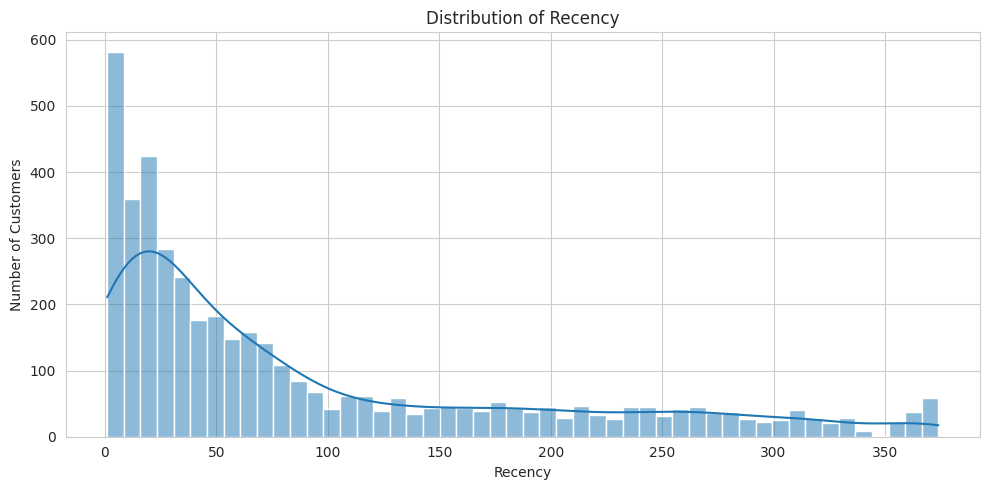

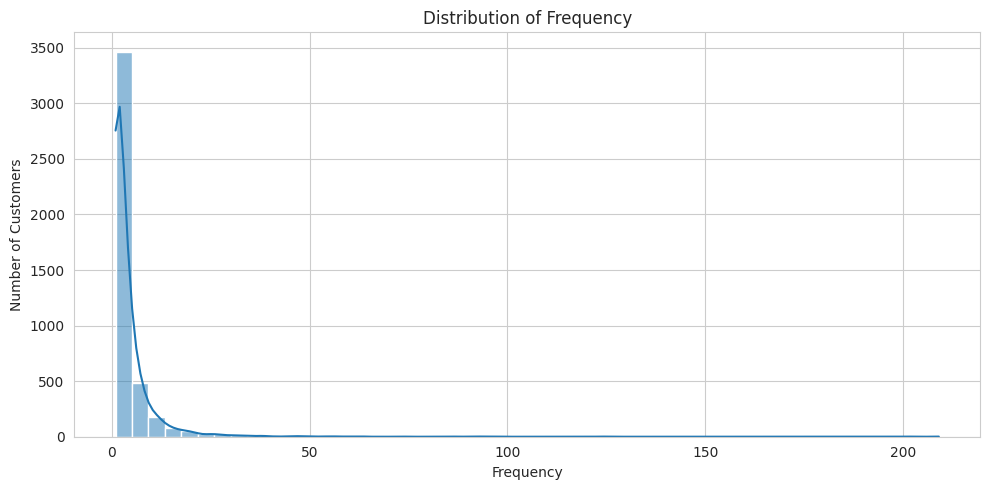

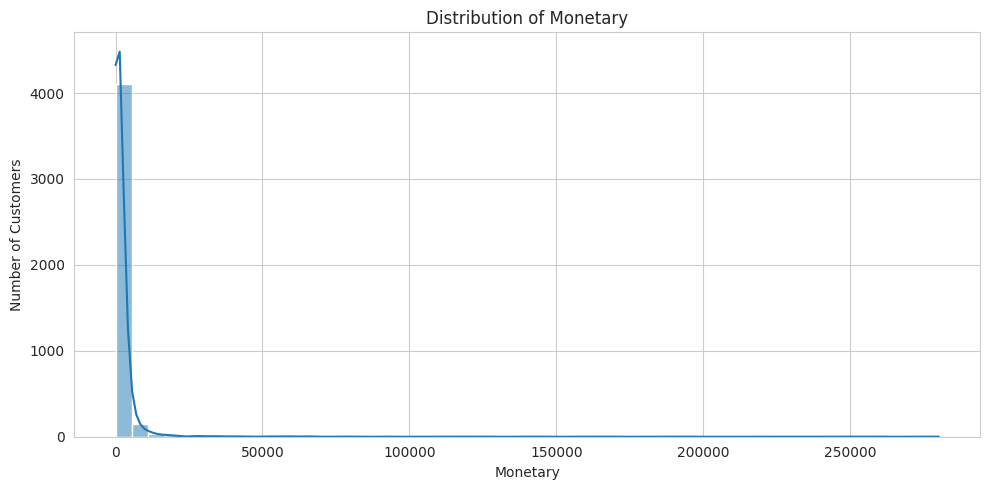

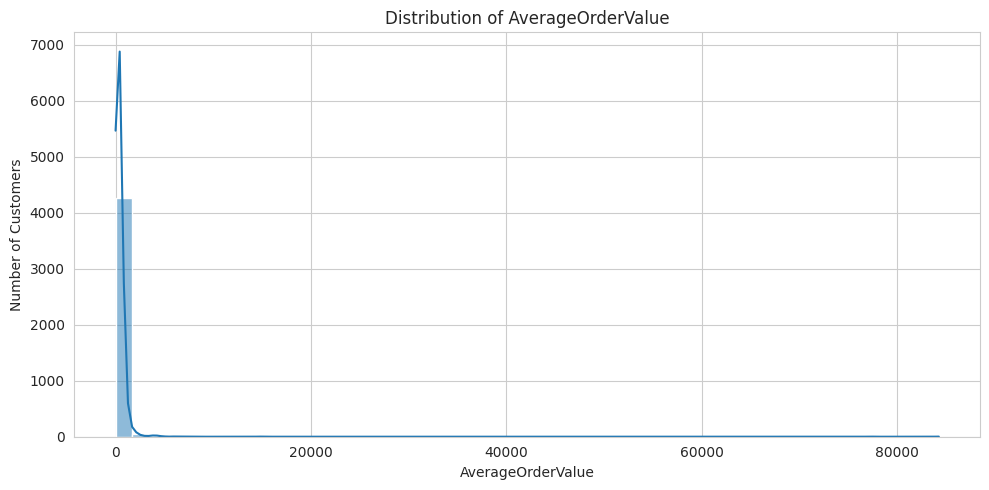

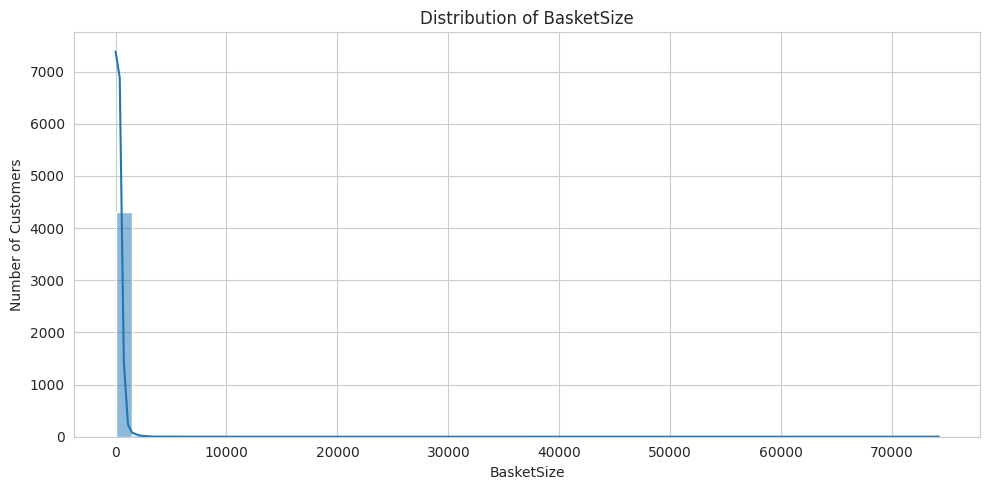

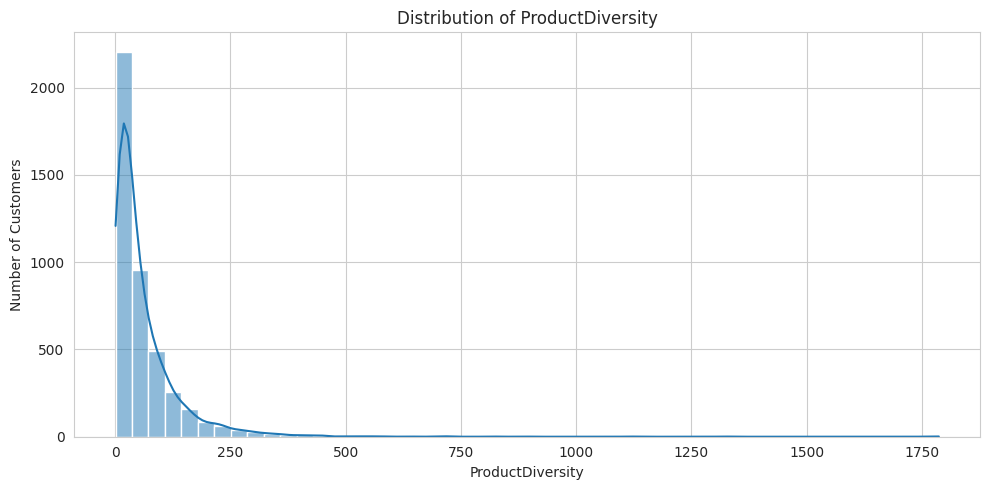

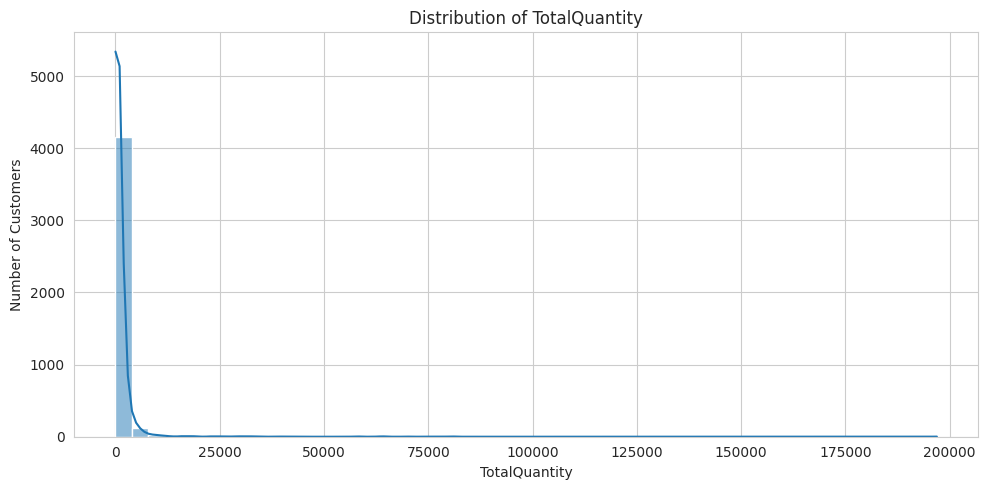

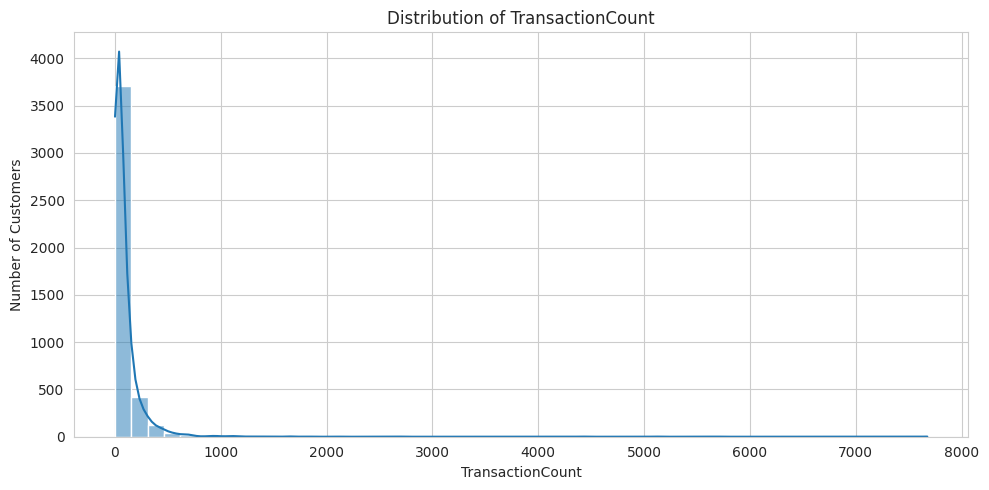

In [34]:
# FEATURE DISTRIBUTIONS

feature_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity",
    "TransactionCount"
]

for col in feature_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(customer_features[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.savefig(
        os.path.join(figures_dir, f"{col}_distribution.png"),
        dpi=300
    )
    plt.show()


##  11: Examining the  possible outliers using boxplots




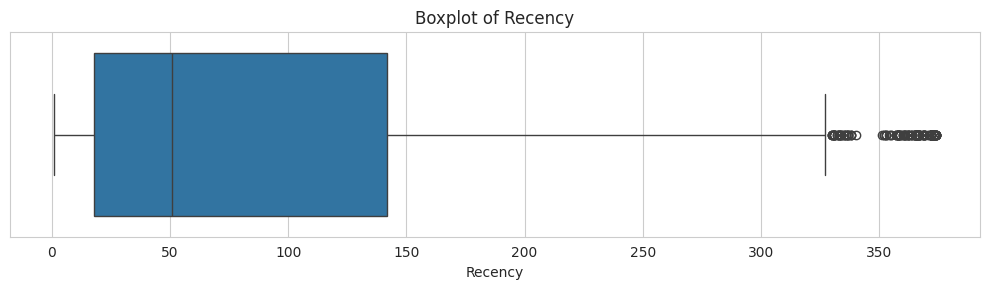

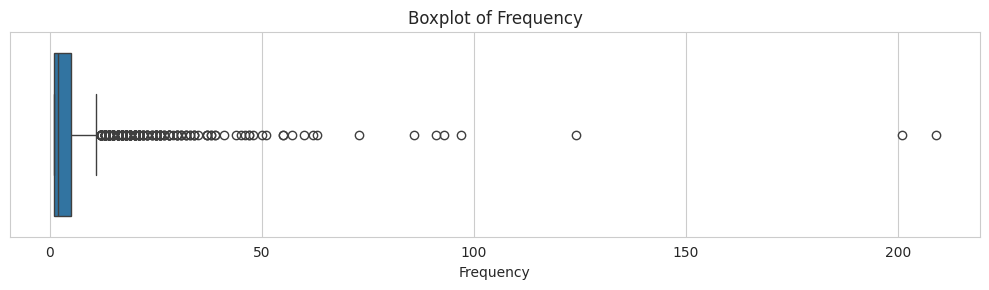

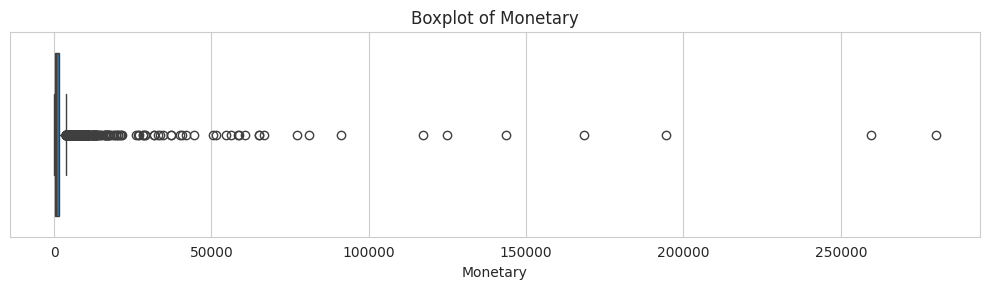

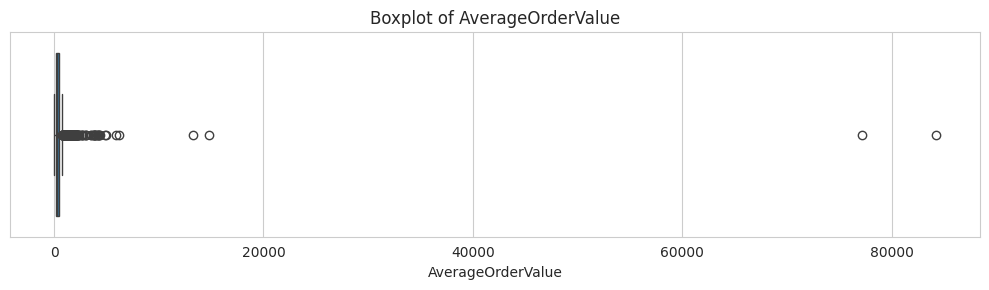

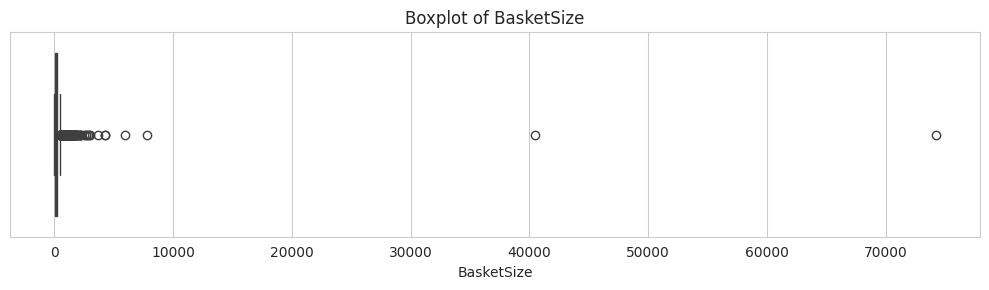

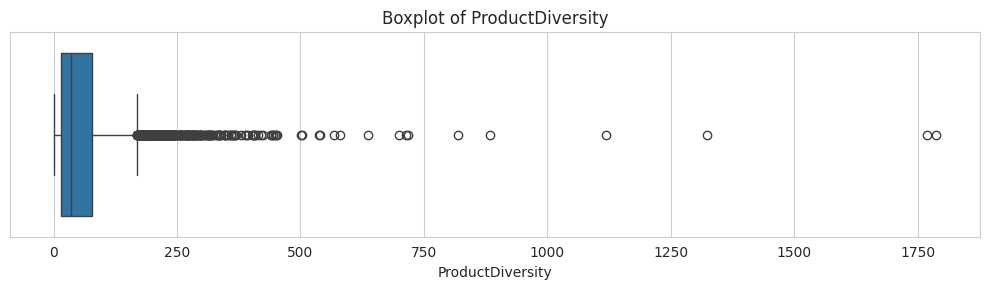

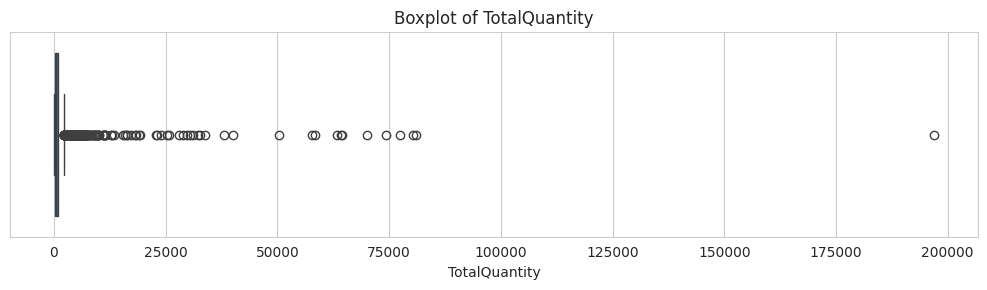

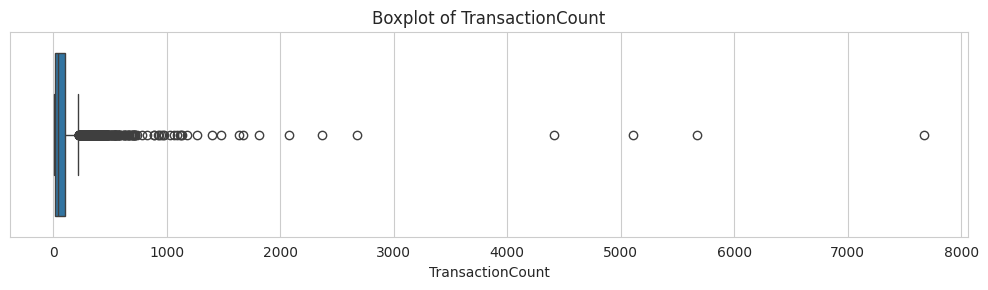

In [35]:
# BOXPLOTS FOR FEATURE OUTLIERS

for col in feature_cols:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=customer_features[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(figures_dir, f"{col}_boxplot.png"),
        dpi=300
    )
    plt.show()


## 12: Check correlation between features




,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity,TransactionCount
Recency,1.000000,-0.260578,-0.121831,-0.000116,0.007424,-0.300728,-0.123449,-0.206444
Frequency,-0.260578,1.000000,0.552780,0.019130,0.010800,0.692223,0.557216,0.757042
Monetary,-0.121831,0.552780,1.000000,0.393667,0.310523,0.385826,0.922942,0.425282
AverageOrderValue,-0.000116,0.019130,0.393667,1.000000,0.930907,0.035964,0.406581,0.030531
BasketSize,0.007424,0.010800,0.310523,0.930907,1.000000,0.024758,0.384052,0.018653
ProductDiversity,-0.300728,0.692223,0.385826,0.035964,0.024758,1.000000,0.408819,0.876773
TotalQuantity,-0.123449,0.557216,0.922942,0.406581,0.384052,0.408819,1.000000,0.433156
TransactionCount,-0.206444,0.757042,0.425282,0.030531,0.018653,0.876773,0.433156,1.000000


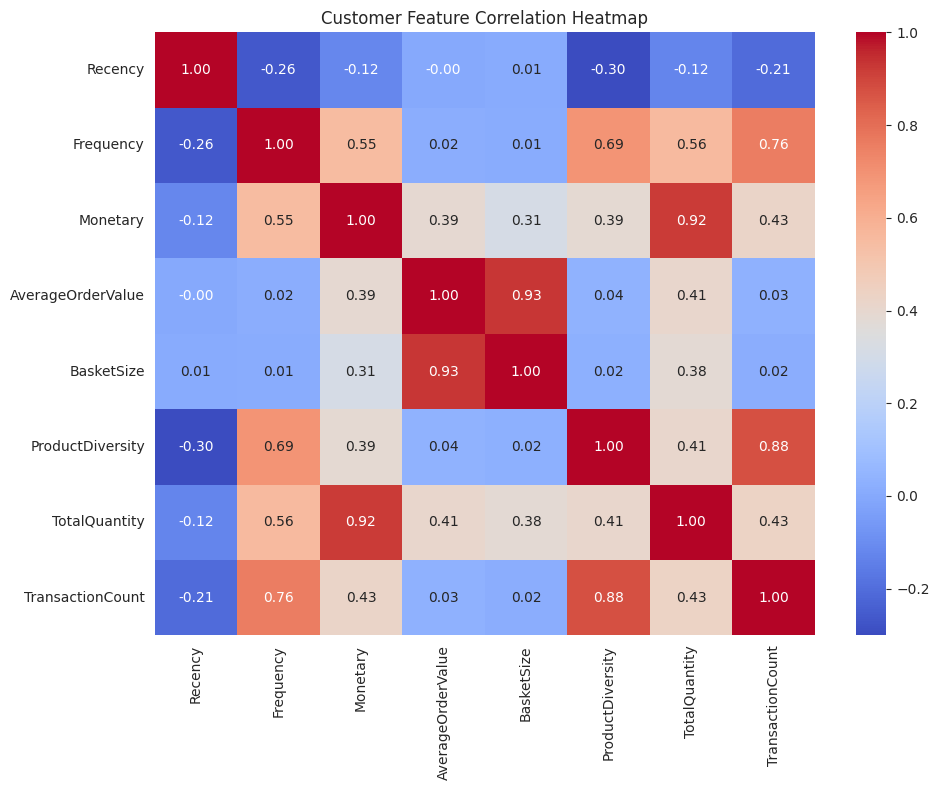

In [36]:
# CORRELATION CHECK

correlation_matrix = customer_features[feature_cols].corr()

display(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Customer Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, "customer_feature_correlation_heatmap.png"),
    dpi=300
)
plt.show()


##  13:  final feature quality report


In [37]:
# FINAL CUSTOMER FEATURE QUALITY REPORT

customer_feature_report = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Features",
        "Missing Values",
        "Duplicate Customer IDs",
        "Average Recency",
        "Average Frequency",
        "Average Monetary",
        "Average Order Value",
        "Average Basket Size",
        "Average Product Diversity"
    ],
    "Value": [
        customer_features["CustomerID"].nunique(),
        customer_features.shape[1],
        customer_features.isnull().sum().sum(),
        customer_features["CustomerID"].duplicated().sum(),
        round(customer_features["Recency"].mean(), 2),
        round(customer_features["Frequency"].mean(), 2),
        round(customer_features["Monetary"].mean(), 2),
        round(customer_features["AverageOrderValue"].mean(), 2),
        round(customer_features["BasketSize"].mean(), 2),
        round(customer_features["ProductDiversity"].mean(), 2)
    ]
})

display(customer_feature_report)

customer_feature_report.to_csv(
    os.path.join(tables_dir, "customer_feature_report.csv"),
    index=False
)


,Metric,Value
0,Total Customers,4338.00
1,Total Features,9.00
2,Missing Values,0.00
3,Duplicate Customer IDs,0.00
4,Average Recency,92.54
5,Average Frequency,4.27
6,Average Monetary,2048.69
7,Average Order Value,417.65
8,Average Basket Size,252.46
9,Average Product Diversity,61.50


## Block 14: Export the customer feature dataset

The final customer-level data will be saved for the preprocessing and K-Means stages.


In [38]:
# EXPORT CUSTOMER FEATURE DATASET

customer_features.to_csv(
    os.path.join(data_dir, "customer_features_ready_for_preprocessing.csv"),
    index=False
)

print("="*70)
print("CUSTOMER FEATURE ENGINEERING COMPLETED SUCCESSFULLY")
print("="*70)

print("\nCustomer-level feature dataset saved as:")
print(os.path.join(data_dir, "customer_features_ready_for_preprocessing.csv"))

print("\nFinal Customer Feature Shape:")
print(customer_features.shape)

display(customer_features.head())


CUSTOMER FEATURE ENGINEERING COMPLETED SUCCESSFULLY

Customer-level feature dataset saved as:
Results/Data/customer_features_ready_for_preprocessing.csv

Final Customer Feature Shape:
(4338, 9)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,ProductDiversity,TransactionCount,AverageOrderValue,BasketSize
0,12346,326,1,77183.60,74215,1,1,77183.60,74215.00
1,12347,2,7,4310.00,2458,103,182,615.71,351.14
2,12348,75,4,1797.24,2341,22,31,449.31,585.25
3,12349,19,1,1757.55,631,73,73,1757.55,631.00
4,12350,310,1,334.40,197,17,17,334.40,197.00
